# # Transaction Risk Intelligence – Phase 1 (Modeling on fraudTrain)

In this notebook we build and evaluate anomaly and fraud detection models on
the `fraudTrain` dataset, then prepare them for reuse in later phases.


## 1. Imports and configuration

In [1]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, accuracy_score, classification_report, precision_recall_fscore_support, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_recall_curve

import joblib

## 2. Data loading and initial inspection

We load the Kaggle `fraudTrain.csv` file and quickly inspect its structure and
class balance.

In [2]:
train_path = "/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv"
df=pd.read_csv(train_path)
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [4]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

## 3. Data cleaning and type optimization

We drop columns not needed for modeling and convert numeric and categorical
columns to efficient dtypes to reduce memory usage.

In [5]:
uncolu=['Unnamed: 0','first','last', 'gender', 'street', 'job', 'dob', 'trans_num']

df_clean=df.drop(uncolu, axis=1)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 15 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   city                   1296675 non-null  object 
 6   state                  1296675 non-null  object 
 7   zip                    1296675 non-null  int64  
 8   lat                    1296675 non-null  float64
 9   long                   1296675 non-null  float64
 10  city_pop               1296675 non-null  int64  
 11  unix_time              1296675 non-null  int64  
 12  merch_lat              1296675 non-null  float64
 13  merch_long             1296675 non-null  float64
 14  is_fraud          

In [6]:
df_clean=df_clean.astype({
    'amt':'float32',
    'lat':'float16',
    'long':'float16',
    'merch_lat':'float16',
    'merch_long':'float16',
    'city':'category',
    'state':'category',
    'category': 'category'
})

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 15 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   trans_date_trans_time  1296675 non-null  object  
 1   cc_num                 1296675 non-null  int64   
 2   merchant               1296675 non-null  object  
 3   category               1296675 non-null  category
 4   amt                    1296675 non-null  float32 
 5   city                   1296675 non-null  category
 6   state                  1296675 non-null  category
 7   zip                    1296675 non-null  int64   
 8   lat                    1296675 non-null  float16 
 9   long                   1296675 non-null  float16 
 10  city_pop               1296675 non-null  int64   
 11  unix_time              1296675 non-null  int64   
 12  merch_lat              1296675 non-null  float16 
 13  merch_long             1296675 non-null  float16 
 14  is

## 4. Transaction ordering baseline table

We sort transactions by card and time to create `df_base`, which is the base
table for all downstream feature engineering.

In [8]:
# Ordering df
df_base=df_clean.sort_values(['cc_num', 'unix_time']).reset_index(drop=True)
df_base.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,trans_date_trans_time,cc_num,merchant,category,amt,city,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.270000,Fort Washakie,WY,82514,43.0,-108.875,1645,1325422035,43.96875,-109.7500,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.939999,Fort Washakie,WY,82514,43.0,-108.875,1645,1325493897,42.03125,-109.0625,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.080002,Fort Washakie,WY,82514,43.0,-108.875,1645,1325494056,42.96875,-109.1875,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.790001,Fort Washakie,WY,82514,43.0,-108.875,1645,1325507894,42.21875,-108.7500,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.180000,Fort Washakie,WY,82514,43.0,-108.875,1645,1325509846,43.31250,-108.0625,0


## 5. Temporal feature – time since previous transaction

For each card we compute the time since the previous transaction in seconds,
capturing short bursts versus long gaps in activity.


In [9]:
# Assigning a new feature, 1
df_base=df_base.assign(
    time_since_prev=(df_base.groupby('cc_num')['unix_time'].diff()).fillna(0)
)
df_base.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,trans_date_trans_time,cc_num,merchant,category,amt,city,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,time_since_prev
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.270000,Fort Washakie,WY,82514,43.0,-108.875,1645,1325422035,43.96875,-109.7500,0,0.0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.939999,Fort Washakie,WY,82514,43.0,-108.875,1645,1325493897,42.03125,-109.0625,0,71862.0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.080002,Fort Washakie,WY,82514,43.0,-108.875,1645,1325494056,42.96875,-109.1875,0,159.0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.790001,Fort Washakie,WY,82514,43.0,-108.875,1645,1325507894,42.21875,-108.7500,0,13838.0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.180000,Fort Washakie,WY,82514,43.0,-108.875,1645,1325509846,43.31250,-108.0625,0,1952.0


## 6. Rolling behaviour features (last 10 transactions)

We build 10-transaction rolling statistics per card to characterise short-term
spending patterns: average amount, variability, and transaction count.

In [10]:
# Assigning new features, 4
window = 10
grp = df_base.groupby("cc_num")["amt"]

df_base["amt_roll_mean_10"] = grp.transform(
    lambda x: x.rolling(window, min_periods=1).mean()
)
df_base["amt_roll_std_10"] = grp.transform(
    lambda x: x.rolling(window, min_periods=1).std().fillna(0)
)
df_base["txn_count_10"] = grp.transform(
    lambda x: x.rolling(window, min_periods=1).count()
)
# grp.count()
df_base.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,trans_date_trans_time,cc_num,merchant,category,amt,city,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,time_since_prev,amt_roll_mean_10,amt_roll_std_10,txn_count_10
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.270000,Fort Washakie,WY,82514,43.0,-108.875,1645,1325422035,43.96875,-109.7500,0,0.0,7.270000,0.000000,1.0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.939999,Fort Washakie,WY,82514,43.0,-108.875,1645,1325493897,42.03125,-109.0625,0,71862.0,30.104999,32.293566,2.0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.080002,Fort Washakie,WY,82514,43.0,-108.875,1645,1325494056,42.96875,-109.1875,0,159.0,47.430000,37.708144,3.0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.790001,Fort Washakie,WY,82514,43.0,-108.875,1645,1325507894,42.21875,-108.7500,0,13838.0,44.270000,31.430535,4.0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.180000,Fort Washakie,WY,82514,43.0,-108.875,1645,1325509846,43.31250,-108.0625,0,1952.0,40.852000,28.272292,5.0


## 7. First feature set for unsupervised anomaly detection

We assemble an initial numeric feature set for Isolation Forest using amount,
timing, and rolling behaviour variables.

In [11]:
# Created a dedicated feature set for training 

feature_cols=['amt', 'time_since_prev', 'amt_roll_mean_10',	'amt_roll_std_10', 'txn_count_10']

X=df_base[feature_cols].astype('float32')
y=df_base['is_fraud'].astype('int8')
X

,amt,time_since_prev,amt_roll_mean_10,amt_roll_std_10,txn_count_10
0,7.270000,0.0,7.270000,0.000000,1.0
1,52.939999,71862.0,30.105000,32.293564,2.0
2,82.080002,159.0,47.430000,37.708145,3.0
3,34.790001,13838.0,44.270000,31.430534,4.0
4,27.180000,1952.0,40.852001,28.272291,5.0
...,...,...,...,...,...
1296670,60.470001,30740.0,14.118000,21.603981,10.0
1296671,74.290001,12962.0,21.205999,28.292517,10.0
1296672,246.559998,7618.0,41.000000,76.969742,10.0
1296673,2.620000,18989.0,41.158001,76.880173,10.0


In [12]:
# Scaling

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

## 8. First Isolation Forest baseline

We train an initial Isolation Forest model on the scaled feature set and
evaluate its precision, recall, F1, and PR–AUC against true fraud labels.


In [13]:
# Initialize first isolation forest model
iso=IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

IsolationForest(contamination=0.01, n_jobs=-1, random_state=42)

In [14]:
scores=iso.decision_function(X_scaled)
pred_labels=iso.predict(X_scaled)
df_base=df_base.assign(
    anomaly_score=scores,
    anomaly_iforest=(pred_labels==-1).astype('int8')
)
df_base.head()
# pred_labels==-1

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,trans_date_trans_time,cc_num,merchant,category,amt,city,state,zip,lat,long,...,unix_time,merch_lat,merch_long,is_fraud,time_since_prev,amt_roll_mean_10,amt_roll_std_10,txn_count_10,anomaly_score,anomaly_iforest
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.270000,Fort Washakie,WY,82514,43.0,-108.875,...,1325422035,43.96875,-109.7500,0,0.0,7.270000,0.000000,1.0,0.017870,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.939999,Fort Washakie,WY,82514,43.0,-108.875,...,1325493897,42.03125,-109.0625,0,71862.0,30.104999,32.293566,2.0,0.051701,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.080002,Fort Washakie,WY,82514,43.0,-108.875,...,1325494056,42.96875,-109.1875,0,159.0,47.430000,37.708144,3.0,0.103514,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.790001,Fort Washakie,WY,82514,43.0,-108.875,...,1325507894,42.21875,-108.7500,0,13838.0,44.270000,31.430535,4.0,0.121917,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.180000,Fort Washakie,WY,82514,43.0,-108.875,...,1325509846,43.31250,-108.0625,0,1952.0,40.852000,28.272292,5.0,0.130259,0


In [15]:
precision=precision_score(y, df_base['anomaly_iforest'])
recall=recall_score(y, df_base['anomaly_iforest'])
f1=f1_score(y, df_base['anomaly_iforest'])
pr_auc=average_precision_score(y, -df_base['anomaly_iforest'])

In [16]:
# Check the scores of our first unsupervised model
precision, recall, f1, pr_auc

(0.27161255494717357,
 0.469224620303757,
 0.3440629121281688,
 np.float64(0.004363444360918022))

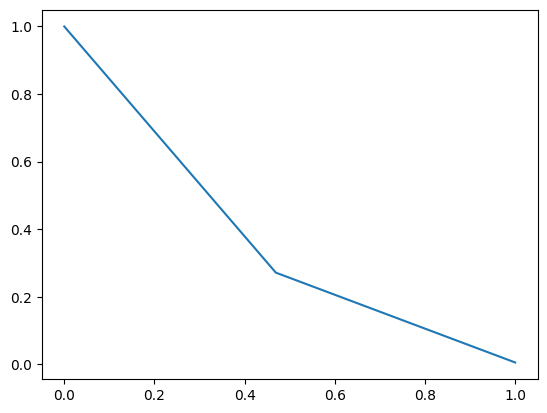

In [17]:
# a look at our first pr curve
precisions, recalls, thresholds = precision_recall_curve(y, df_base['anomaly_iforest'])
fig, axes=plt.subplots()

axes.plot(recalls, precisions);

## 9. Spatial feature – customer–merchant distance

We use the Haversine formula to compute the distance between customer and
merchant locations, capturing suspicious geography patterns.

In [18]:
# Adding new feature, 5

import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    """
    Approximate great-circle distance between (lat1, lon1) and (lat2, lon2) in km.
    All inputs are in degrees.
    """
    R = 6371.0  # Earth radius in kilometers

    # Convert degrees to radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# Create the new feature
df_base["dist_cust_merchant_km"] = haversine(
    df_base["lat"],
    df_base["long"],
    df_base["merch_lat"],
    df_base["merch_long"],
).astype("float32")

df_base.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,trans_date_trans_time,cc_num,merchant,category,amt,city,state,zip,lat,long,...,merch_lat,merch_long,is_fraud,time_since_prev,amt_roll_mean_10,amt_roll_std_10,txn_count_10,anomaly_score,anomaly_iforest,dist_cust_merchant_km
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.270000,Fort Washakie,WY,82514,43.0,-108.875,...,43.96875,-109.7500,0,0.0,7.270000,0.000000,1.0,0.017870,0,128.250000
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.939999,Fort Washakie,WY,82514,43.0,-108.875,...,42.03125,-109.0625,0,71862.0,30.104999,32.293566,2.0,0.051701,0,109.750000
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.080002,Fort Washakie,WY,82514,43.0,-108.875,...,42.96875,-109.1875,0,159.0,47.430000,37.708144,3.0,0.103514,0,23.078125
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.790001,Fort Washakie,WY,82514,43.0,-108.875,...,42.21875,-108.7500,0,13838.0,44.270000,31.430535,4.0,0.121917,0,87.625000
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.180000,Fort Washakie,WY,82514,43.0,-108.875,...,43.31250,-108.0625,0,1952.0,40.852000,28.272292,5.0,0.130259,0,76.250000


## 10. Improved Isolation Forest with distance feature

We extend the feature set with customer–merchant distance, retrain Isolation
Forest, and re-evaluate anomaly detection quality.


In [19]:
feature_cols=['amt', 'time_since_prev', 'amt_roll_mean_10',	'amt_roll_std_10', 'txn_count_10', 'dist_cust_merchant_km']

X=df_base[feature_cols].astype('float32')
y=df_base['is_fraud'].astype('int8')
X

,amt,time_since_prev,amt_roll_mean_10,amt_roll_std_10,txn_count_10,dist_cust_merchant_km
0,7.270000,0.0,7.270000,0.000000,1.0,128.250000
1,52.939999,71862.0,30.105000,32.293564,2.0,109.750000
2,82.080002,159.0,47.430000,37.708145,3.0,23.078125
3,34.790001,13838.0,44.270000,31.430534,4.0,87.625000
4,27.180000,1952.0,40.852001,28.272291,5.0,76.250000
...,...,...,...,...,...,...
1296670,60.470001,30740.0,14.118000,21.603981,10.0,78.312500
1296671,74.290001,12962.0,21.205999,28.292517,10.0,57.125000
1296672,246.559998,7618.0,41.000000,76.969742,10.0,113.937500
1296673,2.620000,18989.0,41.158001,76.880173,10.0,59.937500


In [20]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

iso=IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

IsolationForest(contamination=0.01, n_jobs=-1, random_state=42)

In [21]:
scores = iso.decision_function(X_scaled)
pred_labels = iso.predict(X_scaled)
df_base["anomaly_iforest_dist"] = (pred_labels == -1).astype("int8")

precision = precision_score(y, df_base["anomaly_iforest_dist"])
recall = recall_score(y, df_base["anomaly_iforest_dist"])
f1 = f1_score(y, df_base["anomaly_iforest_dist"])
pr_auc = average_precision_score(y, -scores)

precision, recall, f1, pr_auc

(0.30122618955810904,
 0.5203836930455635,
 0.3815757338934206,
 np.float64(0.2632603448576576))

## 11. Daily spending features per card

We aggregate transactions per card and day to compute total amount, number of
transactions, and maximum amount, capturing daily behaviour.

In [22]:
#Adding new feature, 8
df_base['trans_datetime']=pd.to_datetime(df_base['trans_date_trans_time'])
df_base['trans_date']=df_base['trans_datetime'].dt.date

# pd.DataFrame(df_base.groupby(['cc_num', 'trans_date'])['amt'].max())
g_day=df_base.groupby(['cc_num', 'trans_date'])['amt']

df_base['amt_day_sum']=g_day.transform('sum').astype('float32')
df_base['amt_day_count']=g_day.transform('count').astype('float32')
df_base['amt_day_max']=g_day.transform('max').astype('float32')

# g_day.max()
df_base.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,trans_date_trans_time,cc_num,merchant,category,amt,city,state,zip,lat,long,...,txn_count_10,anomaly_score,anomaly_iforest,dist_cust_merchant_km,anomaly_iforest_dist,trans_datetime,trans_date,amt_day_sum,amt_day_count,amt_day_max
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.270000,Fort Washakie,WY,82514,43.0,-108.875,...,1.0,0.017870,0,128.250000,0,2019-01-01 12:47:15,2019-01-01,7.270000,1.0,7.270000
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.939999,Fort Washakie,WY,82514,43.0,-108.875,...,2.0,0.051701,0,109.750000,0,2019-01-02 08:44:57,2019-01-02,196.990005,4.0,82.080002
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.080002,Fort Washakie,WY,82514,43.0,-108.875,...,3.0,0.103514,0,23.078125,0,2019-01-02 08:47:36,2019-01-02,196.990005,4.0,82.080002
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.790001,Fort Washakie,WY,82514,43.0,-108.875,...,4.0,0.121917,0,87.625000,0,2019-01-02 12:38:14,2019-01-02,196.990005,4.0,82.080002
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.180000,Fort Washakie,WY,82514,43.0,-108.875,...,5.0,0.130259,0,76.250000,0,2019-01-02 13:10:46,2019-01-02,196.990005,4.0,82.080002


In [23]:
feature_cols = [
    "amt",
    "time_since_prev",
    "amt_roll_mean_10",
    "amt_roll_std_10",
    "txn_count_10",
    "dist_cust_merchant_km",
    "amt_day_sum",
    "amt_day_count",
    "amt_day_max",
]

X = df_base[feature_cols].astype("float32")
y = df_base["is_fraud"].astype("int8")

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,   # same operating point
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

scores = iso.decision_function(X_scaled)
pred_labels = iso.predict(X_scaled)
df_base["anomaly_iforest_daily"] = (pred_labels == -1).astype("int8")

In [25]:
precision = precision_score(y, df_base["anomaly_iforest_daily"])
recall = recall_score(y, df_base["anomaly_iforest_daily"])
f1 = f1_score(y, df_base["anomaly_iforest_daily"])
pr_auc = average_precision_score(y, -scores)

precision, recall, f1, pr_auc

(0.40911544690367857,
 0.7067679189981348,
 0.5182435402725541,
 np.float64(0.4331263806436029))

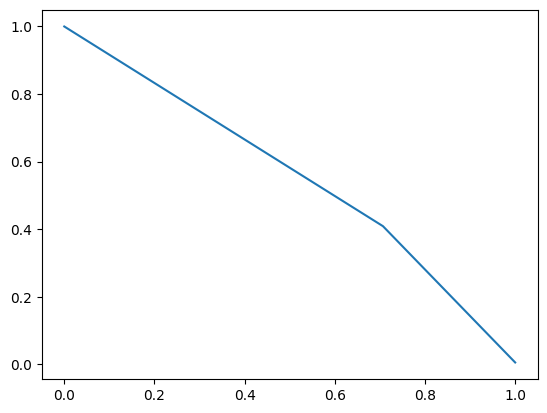

In [26]:
precisions, recalls, thresholds = precision_recall_curve(y, df_base['anomaly_iforest_daily'])
fig, axes=plt.subplots()

axes.plot(recalls, precisions);

In [27]:
# Final feature list for our unsupervised learning approach using isolation forest
feature_cols = [
    "amt",
    "time_since_prev",
    "amt_roll_mean_10",
    "amt_roll_std_10",
    "txn_count_10",
    "dist_cust_merchant_km",
    "amt_day_sum",
    "amt_day_count",
    "amt_day_max",
]

X = df_base[feature_cols].astype("float32")
y = df_base["is_fraud"].astype("int8")

## 12. Final tuned Isolation Forest (unsupervised baseline)

Using the full feature set (temporal, rolling, distance, and daily features),
we tune Isolation Forest hyperparameters and obtain our final unsupervised
baseline metrics.

In [28]:
# Our final unsupervised model for anomaly detection and it's scores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    max_samples=100,
    random_state=42,
    n_jobs=-1,
    max_features=0.9
)
iso.fit(X_scaled)

scores = iso.decision_function(X_scaled)
pred_labels = iso.predict(X_scaled)
df_base["anomaly_iforest_best"] = (pred_labels == -1).astype("int8")

precision = precision_score(y, df_base["anomaly_iforest_best"])
recall = recall_score(y, df_base["anomaly_iforest_best"])
f1 = f1_score(y, df_base["anomaly_iforest_best"])
pr_auc = average_precision_score(y, -scores)

precision, recall, f1, pr_auc

(0.4243078584098095,
 0.7330135891286971,
 0.5374883993552484,
 np.float64(0.4754260911639586))

Text(0.5, 0, 'Recall')

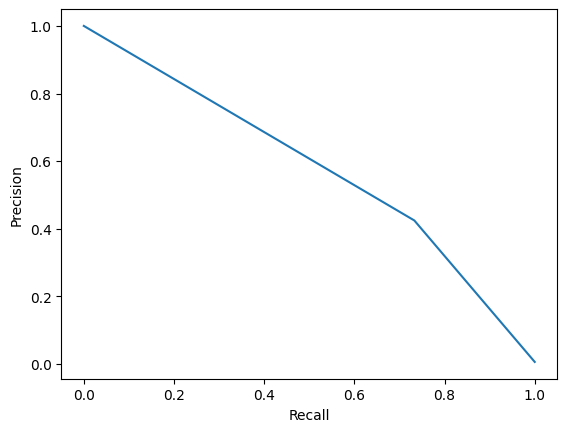

In [29]:
# checking the pr curve for our unsupervised model
precisions, recalls, thresholds = precision_recall_curve(y, df_base['anomaly_iforest_best'])
fig, axes=plt.subplots()

axes.plot(recalls, precisions);
axes.set_ylabel('Precision')
axes.set_xlabel('Recall')

## 13. Adding Isolation Forest score as supervised feature

We convert the Isolation Forest score into a feature and join it with our
engineered variables, then create a stratified train/test split for supervision.

In [30]:
# Starting supervised Journey
# Adding isolation forest scores as a feature to our main dataframe(df_base)
df_base['iforest_score']= -scores

sup_features= feature_cols + ['iforest_score']

X=df_base[sup_features]
y=df_base['is_fraud']

In [31]:
# stratified split of 30%(test), 70%(training)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

## 14. Supervised RandomForest model – training

We train a class-weighted RandomForest classifier on the supervised feature
set, learning to predict `is_fraud` directly.

In [32]:
# Our final supervised model(using random forest) initialization and training on training set
rf=RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

## 15. RandomForest evaluation on hold-out test set

We evaluate the RandomForest on the test split, reporting precision, recall,
F1, PR–AUC, ROC–AUC, FPR, and the confusion matrix at threshold 0.5.

In [33]:
# scores on the random forest model
probs = rf.predict_proba(X_test)[:, 1]
y_pred = (probs >= 0.5).astype(int)
# y_pred = probs

prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary"
)
pr_auc = average_precision_score(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc)
print("FPR:", fpr)
print("Confusion matrix:\n", cm)

Precision: 0.9447004608294931
Recall: 0.9103019538188277
F1: 0.9271822704658526
PR-AUC: 0.9665795684532668
ROC-AUC: 0.9977934637361714
FPR: 0.0003102771550687652
Confusion matrix:
 [[386631    120]
 [   202   2050]]


## 16. Precision–recall curve for RandomForest

We visualise the precision–recall tradeoff across thresholds for the
RandomForest model on the test set.

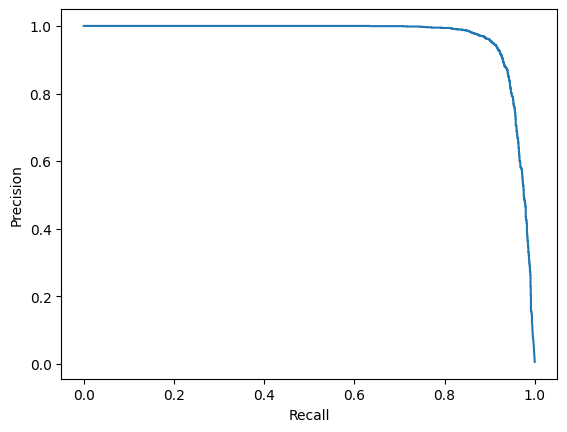

In [34]:
# plotting precision recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
fig, axes=plt.subplots()

axes.plot(recalls, precisions);
axes.set_ylabel('Precision')
axes.set_xlabel('Recall');
# It's in the far right as it should be

## 17. Detailed classification report

We print the full classification report to inspect performance separately for
fraud and non-fraud classes.


In [35]:
''' After you have y_test and y_pred from your model, getting the classification report of our final model for tracking
    fraudulent transactions '''

acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", acc)

print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.999172242887587
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.94      0.91      0.93      2252

    accuracy                           1.00    389003
   macro avg       0.97      0.95      0.96    389003
weighted avg       1.00      1.00      1.00    389003



In [36]:
''' Isolation Forest vs RandomForest – Test Set (Phase 1)

**Isolation Forest (unsupervised baseline)**  
- Precision ≈ 0.42  
- Recall ≈ 0.73  
- F1 ≈ 0.54  
- PR‑AUC ≈ 0.47  

**RandomForest (supervised, threshold 0.5)**  
- Precision ≈ 0.94  
- Recall ≈ 0.91  
- F1 ≈ 0.93  
- PR‑AUC ≈ 0.97  
- FPR ≈ 0.0003  

**RandomForest (supervised, threshold 0.8 – strict mode)**  
- Precision ≈ 0.99  
- Recall ≈ 0.85  
- F1 ≈ 0.91  
- FPR ≈ 0.00007  

RandomForest, trained on labels and engineered features, dramatically improves
both detection rate and false positive control compared to the unsupervised
Isolation Forest baseline, while giving flexible operating points via the
probability threshold.
'''

' Isolation Forest vs RandomForest – Test Set (Phase 1)\n\n**Isolation Forest (unsupervised baseline)**  \n- Precision ≈ 0.42  \n- Recall ≈ 0.73  \n- F1 ≈ 0.54  \n- PR‑AUC ≈ 0.47  \n\n**RandomForest (supervised, threshold 0.5)**  \n- Precision ≈ 0.94  \n- Recall ≈ 0.91  \n- F1 ≈ 0.93  \n- PR‑AUC ≈ 0.97  \n- FPR ≈ 0.0003  \n\n**RandomForest (supervised, threshold 0.8 – strict mode)**  \n- Precision ≈ 0.99  \n- Recall ≈ 0.85  \n- F1 ≈ 0.91  \n- FPR ≈ 0.00007  \n\nRandomForest, trained on labels and engineered features, dramatically improves\nboth detection rate and false positive control compared to the unsupervised\nIsolation Forest baseline, while giving flexible operating points via the\nprobability threshold.\n'

## 19. Saving Phase 1 models for reuse

We persist the tuned Isolation Forest (with its scaler) and the final
RandomForest model to disk so later phases can load them without retraining.


In [37]:
# Making a random forest method

RANDOM_STATE = 42  # keep consistent with rest of notebook
def fit_random_forest(X_train, y_train):
    """
    Train the Phase 1 RandomForest model on given training data.
    Returns the fitted model.
    """
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    return model

In [38]:
# Make a predict proba method to make metrics calculation easier and for easier threshold comparison

def predict_proba_and_metrics(model, X, y, threshold=0.5):
    """
    Compute probabilities, apply a decision threshold, and return metrics.

    Returns a dict with:
    - threshold, precision, recall, f1
    - pr_auc, roc_auc, fpr
    - tn, fp, fn, tp, and confusion matrix.
    """
    probs = model.predict_proba(X)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y, y_pred, average="binary"
    )
    pr_auc = average_precision_score(y, probs)
    roc_auc = roc_auc_score(y, probs)
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)

    return {
        "threshold": threshold,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "fpr": fpr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "cm": cm,
    }

In [39]:
# Save model for further use through joblib

joblib.dump(rf, "rf_phase1_final.joblib")

# Optionally, also save Isolation Forest and its scaler for reuse
joblib.dump(iso, "iforest_phase1_final.joblib")
joblib.dump(scaler, "iforest_scaler_phase1.joblib")

print("Saved:")
print(" - rf_phase1_final.joblib")
print(" - iforest_phase1_final.joblib")
print(" - iforest_scaler_phase1.joblib")

Saved:
 - rf_phase1_final.joblib
 - iforest_phase1_final.joblib
 - iforest_scaler_phase1.joblib


## 18. External generalisation test on fraudTest.csv

We load the separate `fraudTest.csv` file, reuse the same feature pipeline, and
measure how well the trained RandomForest generalises.

In [40]:
test_path = "/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv"   
df_test = pd.read_csv(test_path)

# Drop the same unused columns as in train
uncolu = ["Unnamed: 0", "first", "last", "gender", "street", "job", "dob", "trans_num"]
df_test_clean = df_test.drop(uncolu, axis=1)

# Match dtypes you used on train
df_test_clean = df_test_clean.astype({
    "amt": "float32",
    "lat": "float16",
    "long": "float16",
    "merch_lat": "float16",
    "merch_long": "float16",
    "city": "category",
    "state": "category",
    "category": "category",
})

df_test_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   trans_date_trans_time  555719 non-null  object  
 1   cc_num                 555719 non-null  int64   
 2   merchant               555719 non-null  object  
 3   category               555719 non-null  category
 4   amt                    555719 non-null  float32 
 5   city                   555719 non-null  category
 6   state                  555719 non-null  category
 7   zip                    555719 non-null  int64   
 8   lat                    555719 non-null  float16 
 9   long                   555719 non-null  float16 
 10  city_pop               555719 non-null  int64   
 11  unix_time              555719 non-null  int64   
 12  merch_lat              555719 non-null  float16 
 13  merch_long             555719 non-null  float16 
 14  is_fraud            

In [41]:
# Same ordering as train
df_test_base = df_test_clean.sort_values(["cc_num", "unix_time"]).reset_index(drop=True)

# time_since_prev by card
df_test_base = df_test_base.assign(
    time_since_prev=df_test_base.groupby("cc_num")["unix_time"].diff().fillna(0)
)

df_test_base.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,trans_date_trans_time,cc_num,merchant,category,amt,city,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,time_since_prev
0,2020-06-21 13:05:42,60416207185,fraud_Kutch-Ferry,home,124.660004,Fort Washakie,WY,82514,43.0,-108.875,1645,1371819942,42.93750,-108.5000,0,0.0
1,2020-06-21 16:25:36,60416207185,fraud_Halvorson Group,misc_pos,78.519997,Fort Washakie,WY,82514,43.0,-108.875,1645,1371831936,42.18750,-108.6875,0,11994.0
2,2020-06-22 07:58:33,60416207185,fraud_Conroy-Cruickshank,gas_transport,65.250000,Fort Washakie,WY,82514,43.0,-108.875,1645,1371887913,43.93750,-109.6875,0,55977.0
3,2020-06-22 15:32:31,60416207185,fraud_Larkin Ltd,kids_pets,87.739998,Fort Washakie,WY,82514,43.0,-108.875,1645,1371915151,43.53125,-109.1875,0,27238.0
4,2020-06-23 12:28:54,60416207185,fraud_Leffler-Goldner,personal_care,148.020004,Fort Washakie,WY,82514,43.0,-108.875,1645,1371990534,42.87500,-109.3125,0,75383.0


In [42]:
window = 10
grp_test = df_test_base.groupby("cc_num")["amt"]

df_test_base["amt_roll_mean_10"] = grp_test.transform(
    lambda x: x.rolling(window, min_periods=1).mean()
)
df_test_base["amt_roll_std_10"] = grp_test.transform(
    lambda x: x.rolling(window, min_periods=1).std().fillna(0)
)
df_test_base["txn_count_10"] = grp_test.transform(
    lambda x: x.rolling(window, min_periods=1).count()
)

df_test_base[["amt", "time_since_prev", "amt_roll_mean_10", "amt_roll_std_10", "txn_count_10"]].head()


,amt,time_since_prev,amt_roll_mean_10,amt_roll_std_10,txn_count_10
0,124.660004,0.0,124.660004,0.000000,1.0
1,78.519997,11994.0,101.590000,32.625912,2.0
2,65.250000,55977.0,89.476667,31.183707,3.0
3,87.739998,27238.0,89.042500,25.476193,4.0
4,148.020004,75383.0,100.838000,34.386720,5.0


In [43]:
df_test_base["dist_cust_merchant_km"] = haversine(
    df_test_base["lat"],
    df_test_base["long"],
    df_test_base["merch_lat"],
    df_test_base["merch_long"],
).astype("float32")

df_test_base["dist_cust_merchant_km"].head()

0     32.46875
1     92.06250
2    123.31250
3     63.28125
4     38.46875
Name: dist_cust_merchant_km, dtype: float32

In [44]:
# Create date column from trans_date_trans_time
df_test_base["trans_datetime"] = pd.to_datetime(df_test_base["trans_date_trans_time"])
df_test_base["trans_date"] = df_test_base["trans_datetime"].dt.date

gday_test = df_test_base.groupby(["cc_num", "trans_date"])["amt"]

df_test_base["amt_day_sum"] = gday_test.transform("sum").astype("float32")
df_test_base["amt_day_count"] = gday_test.transform("count").astype("float32")
df_test_base["amt_day_max"] = gday_test.transform("max").astype("float32")

df_test_base[["amt_day_sum", "amt_day_count", "amt_day_max"]].head()


,amt_day_sum,amt_day_count,amt_day_max
0,203.179993,2.0,124.660004
1,203.179993,2.0,124.660004
2,152.989990,2.0,87.739998
3,152.989990,2.0,87.739998
4,169.669998,5.0,148.020004


In [45]:
feature_cols = [
    "amt",
    "time_since_prev",
    "amt_roll_mean_10",
    "amt_roll_std_10",
    "txn_count_10",
    "dist_cust_merchant_km",
    "amt_day_sum",
    "amt_day_count",
    "amt_day_max",
]

X_if_test = df_test_base[feature_cols].astype("float32")
y_test_external = df_test_base["is_fraud"].astype("int8")

X_if_test.shape, y_test_external.shape


((555719, 9), (555719,))

In [46]:
# Load trained IF and its scaler from Phase 1
scaler_if = joblib.load("iforest_scaler_phase1.joblib")
iso = joblib.load("iforest_phase1_final.joblib")

X_scaled_test = scaler_if.transform(X_if_test)
scores_if_test = iso.decision_function(X_scaled_test)   # higher = more normal

df_test_base["iforest_score"] = (-scores_if_test).astype("float32")  # higher = more anomalous

In [47]:
sup_features = feature_cols + ["iforest_score"]

X_test_external = df_test_base[sup_features].astype("float32")
y_test_external = df_test_base["is_fraud"].astype("int8")

rf = joblib.load("rf_phase1_final.joblib")

In [48]:
rf = joblib.load("rf_phase1_final.joblib")

# 2. Get predicted probabilities on fraudTest
probs_ext = rf.predict_proba(X_test_external)[:, 1]

# 3. Evaluate at threshold 0.5
threshold_05 = 0.5
y_pred_05 = (probs_ext >= threshold_05).astype(int)

prec_05, rec_05, f1_05, _ = precision_recall_fscore_support(
    y_test_external, y_pred_05, average="binary"
)
pr_auc_05 = average_precision_score(y_test_external, probs_ext)
roc_auc_05 = roc_auc_score(y_test_external, probs_ext)
cm_05 = confusion_matrix(y_test_external, y_pred_05)
tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
fpr_05 = fp_05 / (fp_05 + tn_05)

print("=== fraudTest – RF @ 0.5 ===")
print("Precision:", prec_05)
print("Recall:", rec_05)
print("F1:", f1_05)
print("PR-AUC:", pr_auc_05)
print("ROC-AUC:", roc_auc_05)
print("FPR:", fpr_05)
print("Confusion matrix:\n", cm_05)

# Optional: accuracy + full report
acc_05 = accuracy_score(y_test_external, y_pred_05)
print("\nAccuracy:", acc_05)
print(classification_report(y_test_external, y_pred_05))

# 4. Evaluate at stricter threshold 0.8
threshold_08 = 0.8
y_pred_08 = (probs_ext >= threshold_08).astype(int)

prec_08, rec_08, f1_08, _ = precision_recall_fscore_support(
    y_test_external, y_pred_08, average="binary"
)
cm_08 = confusion_matrix(y_test_external, y_pred_08)
tn_08, fp_08, fn_08, tp_08 = cm_08.ravel()
fpr_08 = fp_08 / (fp_08 + tn_08)

print("\n=== fraudTest – RF @ 0.8 ===")
print("Precision:", prec_08)
print("Recall:", rec_08)
print("F1:", f1_08)
print("FPR:", fpr_08)
print("Confusion matrix:\n", cm_08)

=== fraudTest – RF @ 0.5 ===
Precision: 0.903210795718939
Recall: 0.9048951048951049
F1: 0.904052165812762
PR-AUC: 0.941903129793284
ROC-AUC: 0.9904684821429466
FPR: 0.00037574019011008463
Confusion matrix:
 [[553366    208]
 [   204   1941]]

Accuracy: 0.9992586181145507
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.90      0.90      0.90      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.95      0.95    555719
weighted avg       1.00      1.00      1.00    555719


=== fraudTest – RF @ 0.8 ===
Precision: 0.9764705882352941
Recall: 0.8512820512820513
F1: 0.9095890410958904
FPR: 7.948350175405636e-05
Confusion matrix:
 [[553530     44]
 [   319   1826]]
